<a href="https://colab.research.google.com/github/tejinderpa/LangGraphs/blob/graphs/Chatbot-by-langgraphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install langgraph langchain_google_genai langchain_core

In [9]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY_2')

llm = ChatGoogleGenerativeAI(model="gemini-1.5-flash", google_api_key=GOOGLE_API_KEY)

In [3]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [10]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer = checkpointer)

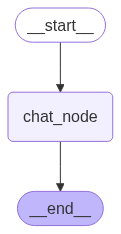

In [6]:
chatbot

In [7]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is **New Delhi**.'

In [13]:
thread_id = '1'

while True:
  user_message = input("Type here:")

  print('User:', user_message)

  if(user_message.strip().lower() in ['exit', 'quit', 'bye']):
    print('Chatbot: Bye!')
    break

  config = {'configurable': {'thread_id' : thread_id}}

  response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config = config)
  print('Chatbot:', response['messages'][-1].content)

Type here:My name is Tej
User: My name is Tej
Chatbot: It's nice to virtually meet you, Tej!  Is there anything I can help you with today?
Type here:I am in NIT Jalandhar
User: I am in NIT Jalandhar
Chatbot: That's great, Tej!  Welcome to NIT Jalandhar.  Are you a student there currently?  What branch are you studying, if you don't mind me asking?  Is there anything specific about NIT Jalandhar or your experience there that you'd like to talk about or ask me about?
Type here:can you guess my age
User: can you guess my age
Chatbot: I cannot guess your age, Tej.  I have no access to personal information about you unless you choose to share it.  My purpose is to help provide information and complete tasks as instructed, not to make guesses about personal details.
Type here:I am doing BTech here, Can you guess age now
User: I am doing BTech here, Can you guess age now
Chatbot: Knowing you're doing a B.Tech at NIT Jalandhar still doesn't allow me to guess your age.  B.Tech programs typicall

In [17]:
import json
import pprint

snapshot = chatbot.get_state(config = config)
# Convert messages to dictionaries before JSON serialization
serializable_messages = []
for message in snapshot.values.get('messages', []):
    serializable_messages.append({'content': message.content, 'type': message.type, 'additional_kwargs': message.additional_kwargs})

serializable_state = {'messages': serializable_messages}

# Use json.dumps for a JSON string representation
print(json.dumps(serializable_state, indent=4))

{
    "messages": [
        {
            "content": "Tell me something about me",
            "type": "human",
            "additional_kwargs": {}
        },
        {
            "content": "I do not have access to personal information about you.  To tell you something about yourself, I would need you to provide me with some information.",
            "type": "ai",
            "additional_kwargs": {}
        },
        {
            "content": "my name is Tej. I live in faridkot",
            "type": "human",
            "additional_kwargs": {}
        },
        {
            "content": "Knowing your name is Tej and you live in Faridkot, Punjab, India, doesn't tell me much about *you* as a person.  That's just location and a name. To tell you something about *you*, I'd need to know your interests, your personality, your aspirations, etc.  Things like:\n\n* What are your hobbies?\n* What kind of work do you do (or are you a student)?\n* What are you passionate about?\n\nTell me more,